In [2]:
import networkx as nx
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt

In [329]:
# In-node
x_in = np.array((0.2, 0.0,))
x_out = np.array((-0.1, 1.0,))

x_cluster1_center = (0.25, 0.3)
x_cluster2_center = (0.1, 0.7)
x_cluster3_center = (-0.4, 0.5)
N_cluster1 = 5
N_cluster2 = 5
N_cluster3 = 5
R_cluster1 = 0.1
R_cluster2 = 0.05
R_cluster3 = 0.1

np.random.seed(0)
rands = np.random.rand(N_cluster1 + N_cluster2 + N_cluster3, 2)

def rand_to_xy(rt):
  ''' Maps rand values (...,2) in range [0,1) to coords in a disk. '''
  # Pick r
  r = np.sqrt(rt[...,0])
  # Pick theta
  th = 2 * np.pi * rt[...,1]
  x = np.zeros_like(rt)
  x[...,0] = r * np.cos(th)
  x[...,1] = r * np.sin(th)
  return x

x_cluster1 = x_cluster1_center + R_cluster1 * rand_to_xy(rands[0:N_cluster1])
x_cluster2 = x_cluster2_center + R_cluster2 * rand_to_xy(
  rands[N_cluster1:N_cluster1+N_cluster2])
x_cluster3 = x_cluster3_center + R_cluster3 * rand_to_xy(
  rands[N_cluster1+N_cluster2:N_cluster1+N_cluster2+N_cluster3])

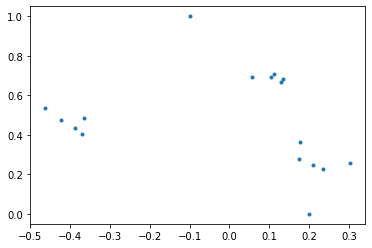

In [330]:
x_nodes = np.concatenate((x_in[np.newaxis,:],
                          x_cluster1, x_cluster2, x_cluster3,
                          x_out[np.newaxis,:],))
plt.plot(x_nodes[:,0], x_nodes[:,1], '.')

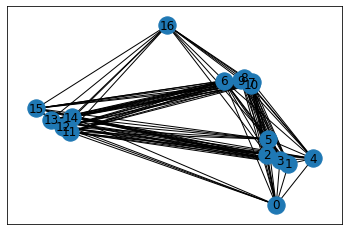

In [331]:
import scipy.spatial
dists = scipy.spatial.distance_matrix(x_nodes, x_nodes)
# Edge set
E = np.divide((dists <= 0.8).astype(float), dists, where=dists>0, out=np.zeros_like(dists))
G = nx.Graph(E,)

length_scale = 1
pos = {i:(n[0] / length_scale, n[1] / length_scale,)
           for (i, n) in enumerate(x_nodes)}
nx.draw_networkx(G, pos,
  # node_size=node_size, node_color=colors,
  # edge_cmap=(0, 1), ax=ax, *args, **kwargs)
)

In [332]:
line_cmap = plt.get_cmap("tab10")

([0, 1, 6, 11, 16, None],
 [array([0], dtype=int64),
  array([4, 1, 3, 2, 5], dtype=int64),
  array([10,  7,  9,  8,  6], dtype=int64),
  array([11, 12, 14, 13, 15], dtype=int64),
  array([16], dtype=int64)])

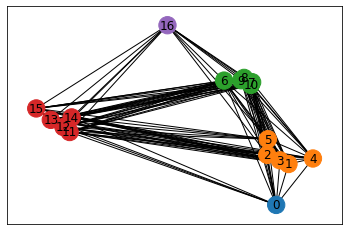

In [333]:
# Eigvec for second-smallest eigenvalue of L
fvec = nx.linalg.algebraicconnectivity.fiedler_vector(G)

# Gradient-based clustering
n_clusters = 5
# Compute indices corresponding to Fiedler order
idx = np.argsort(fvec)
# Compute gradients in eigenvector in descending order
partitions = (np.argsort(np.diff(fvec[idx])) + 1)[::-1]
# Compute boundaries of slices corresponding to each cluster
part_idx = [0, *np.sort(partitions[:n_clusters-1]), None]
# Pick Fiedler indices into each cluster
parts = [idx[part_idx[i_cluster]:part_idx[i_cluster+1]]
         for i_cluster in range(n_clusters)]
# Assign color to each cluster
colors = np.zeros((len(fvec), 4))
for i, part in enumerate(parts):
  colors[part] = line_cmap(i) # np.array([i, i, i, i]) / len(parts)
colors

nx.draw_networkx(G, pos, node_color=colors, # node_size=node_size,
  # edge_cmap=(0, 1), ax=ax, *args, **kwargs)
)
part_idx, parts
# np.argsort(np.diff(fvec[idx]))
# partitions

In [334]:
# Clustered capacity and flow resistance + internal resistance


Physical simulation

In [335]:
import numpy as np
import scipy
import scipy.sparse
import scipy.sparse.linalg
import matplotlib
import matplotlib.cm
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import MagmaChamber, GlobalSystemThreshold

In [336]:
# Set Maxwell times
t_b = 1e11
t_d = 5e10
K_crust = 10e9
G_crust = 10e9
K_f = 10e9
rho0 = 2500

# Constant viscosity assumption
mu0 = 1e6 / 5
# Effective hydraulic radius
r_hydr = 5

# Fix total volume
total_vol = (4/3)*np.pi*1000.0**3
# Fix mass injection
mass_inj = total_vol * rho0 * 0.001

# Network parameters
x_scale = 40000.0
y_scale = 0.0
z_scale = 40000.0 # Depth

In [337]:
# Split volume among constituents
V_node = 1e9

list_nodes = [MagmaChamber(x=x*x_scale, y=0.0, z=z*z_scale,
  p_setting=None, T_setting=1200, V_setting=V_node)
  for (x,z) in x_nodes]

In [338]:
def setup_system(list_nodes, dpdx_crit):
  # Set up for timestepping later
  global_sys = GlobalSystemThreshold(list_nodes, t_b, t_d, K_crust, G_crust,
                                    r_hydr=r_hydr, mu0=mu0, 
                                    rho0=2500, K_f=K_f, Nr=50,
                                    dpdx_crit=dpdx_crit,
                                    dpdx_threshold_scale=0.05 * dpdx_crit,
                                    R_outer_ratio=20,
                                    max_edge_dist=99e9)
                                    # max_edge_dist=10*node_sep)
  # Source term due to mass injection at node 0
  f_inj = global_sys.create_single_mass_injection_source(1.0)
  # Source term due to eruption at node -1
  f_erupt = global_sys.create_eruption_source(p_erupt=2.5e6, mu_erupt=1e5, r_conduit=1000)
  # Time vector
  # t_vec = np.linspace(0, 1000e10//25, 200000//25)
  t_vec = np.linspace(0, 1000e10*2, 200000*2)
  # Display graph
  global_sys.show_network(global_sys.q0)
  
  return (global_sys, t_vec, f_inj, f_erupt)

In [339]:
def run_system(global_sys, t_vec, f_inj, f_erupt):
  q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj, f_erupt)
  m, p, u = global_sys.compute_m_p_u(q_out)
  return (t_vec, m, p, u, q_out, m_erupted_out, global_sys)

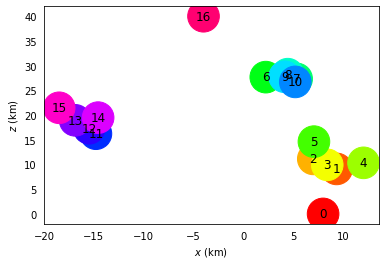

In [340]:
setup = setup_system(list_nodes, 350)
outputs = run_system(*setup)

In [344]:
9

9

In [341]:
_t, _m, _p, _u, _q, _m_out, _gs = outputs

In [345]:
np.savez_compressed("dpdx_modgraph.npz", t=_t, m=_m, p=_p, u=_u, q=_q, m_out=_m_out)

In [346]:
import pickle
with open("dpdx_modgraph_gs.pkl", 'wb') as outp:
  pickle.dump(_gs, outp, pickle.HIGHEST_PROTOCOL)

In [288]:
def get_time_averaged_connectivity(_t, _m, _p, _u, _q, _m_out, _global_sys, averaged=True):
  Nr, num_blocks, block_size = _global_sys.Nr, _global_sys.num_blocks, _global_sys.block_size

  Y = np.zeros((_t.size, num_blocks, num_blocks))

  def smoother(x, scale):
    ''' Returns one-sided compact smoothed step, such that
      1. u(x < -scale) = 0
      2. u(x >= 0) = 1.
      3. u smoothly interpolates from 0 to 1 in between.
    '''
    # Shift, scale, and clip to [-1, 0] to prevent exp overflow
    if scale != 0:
      _x = np.clip(x / scale + 1, 0, 1)
    else:
      _x = np.where(x >= 0, 1, 0)
    f0 = np.exp(-1/np.where(_x == 0, 1, _x))
    f1 = np.exp(-1/np.where(_x == 1, 1, 1-_x))
    # Return piecewise evaluation
    return np.where(_x >= 1, 1,
          np.where(_x <= 0, 0, 
          f0 / (f0 + f1)))

  for i in range(num_blocks):
    node_i = _global_sys.nodes[i]
    for j in range(num_blocks):
      if i == j:
        continue
      node_j = _global_sys.nodes[j]
      # Compute distance
      dist = np.sqrt((node_i.x - node_j.x) ** 2
                      + (node_i.y - node_j.y) ** 2
                      + (node_i.z - node_j.z) ** 2)
      if np.isclose(dist, 0.0):
        raise ValueError("Distance between chamber {i} and {j} is zero.")
      elif dist > _global_sys.max_edge_dist:
        continue
      # Compute average pressure gradient
      dpdx = (_p[:,i] - _p[:,j]) / dist
      # Resolve remote tensile stress in x-direction
      opening_stress = _global_sys.remote_sigma_xx * np.abs(node_i.z - node_j.z)/ dist
      # Effective pressure gradient
      dpdx_eff = dpdx
      # Effective critical pressure gradient for opening
      dpdx_crit_eff = _global_sys.dpdx_crit - opening_stress

      # Factor between (0, 1) that modulates flow between the two chambers
      if dpdx_crit_eff != 0:
        threshold_factor = smoother(np.abs(dpdx_eff) - dpdx_crit_eff,
                                    _global_sys.dpdx_threshold_scale) * (dpdx_eff > 0).astype(float)
        if np.any(threshold_factor > 1) or np.any(threshold_factor < 0):
          raise ValueError
      else:
        threshold_factor = np.ones_like(dpdx_eff)

      # Compute flow admittance ( (m/s) / Pa )
      Y[:,i,j] = threshold_factor * _global_sys.r_hydr * _global_sys.r_hydr / 16.0 / _global_sys.mu0 / dist

  if averaged:
    return Y.mean(axis=0)
  else:
    return Y

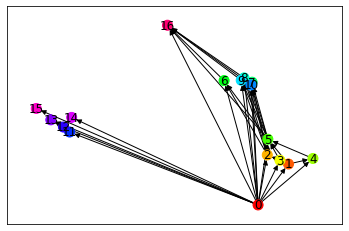

In [328]:
# plt.plot(_m_out)
Y_avg = get_time_averaged_connectivity(*outputs, averaged=True)
# Y = _gs.get_connectivity(_q[-6,:])
G = nx.DiGraph(Y_avg)
node_scale = 100
node_size = node_scale
cmap = matplotlib.cm.hsv
colors =  cmap(np.linspace(0,1,_gs.num_blocks,endpoint=False))

pos = {i:(n[0] / length_scale, n[1] / length_scale,)
           for (i, n) in enumerate(x_nodes)}

nx.draw_networkx(G, pos, node_size=node_size, node_color=colors,
                        edge_cmap=(0, 1), ax=plt.gca())

([0, 1, 12, 13, 14, 15, 16, None],
 [array([14], dtype=int64),
  array([ 7, 10,  8,  9,  4,  6,  5,  1,  3,  2, 16], dtype=int64),
  array([0], dtype=int64),
  array([11], dtype=int64),
  array([12], dtype=int64),
  array([13], dtype=int64),
  array([15], dtype=int64)])

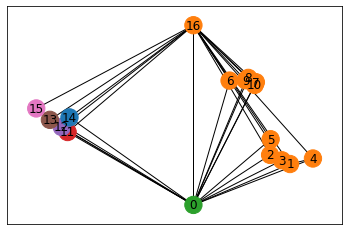

In [55]:
''' Spectral coloring '''

# Eigvec for second-smallest eigenvalue of L
G = nx.Graph(Y_avg)
fvec = nx.linalg.algebraicconnectivity.fiedler_vector(G)

# Gradient-based clustering
n_clusters = 7
# Compute indices corresponding to Fiedler order
idx = np.argsort(fvec)
# Compute gradients in eigenvector in descending order
partitions = (np.argsort(np.diff(fvec[idx])) + 1)[::-1]
# Compute boundaries of slices corresponding to each cluster
part_idx = [0, *np.sort(partitions[:n_clusters-1]), None]
# Pick Fiedler indices into each cluster
parts = [idx[part_idx[i_cluster]:part_idx[i_cluster+1]]
         for i_cluster in range(n_clusters)]
# Assign color to each cluster
colors = np.zeros((len(fvec), 4))
for i, part in enumerate(parts):
  colors[part] = line_cmap(i) # np.array([i, i, i, i]) / len(parts)
colors

nx.draw_networkx(G, pos, node_color=colors, # node_size=node_size,
  # edge_cmap=(0, 1), ax=ax, *args, **kwargs)
)
part_idx, parts

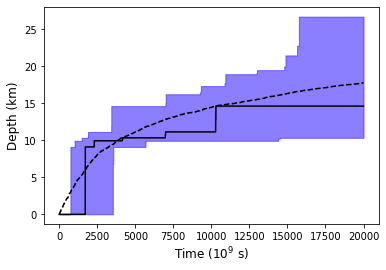

In [342]:
node_i_loc, node_z = _gs.residence_time_sim(_t, _q, N_particles=1000, add_legend=False)

In [343]:
np.savez_compressed("particles_modgraph1.npz", node_i_loc=node_i_loc, node_z=node_z)

In [347]:
''' Reduction to counts, transforming shape (N_t, N_particles) -> (N_t, N_chamber)'''
counts_by_chamber = np.zeros((node_i_loc.shape[0], len(G.nodes),))

for i_t in range(node_i_loc.shape[0]):
  particle_positions = node_i_loc[i_t,:]
  unique, counts = np.unique(particle_positions, return_counts=True)
  counts_by_chamber[i_t, unique] = counts

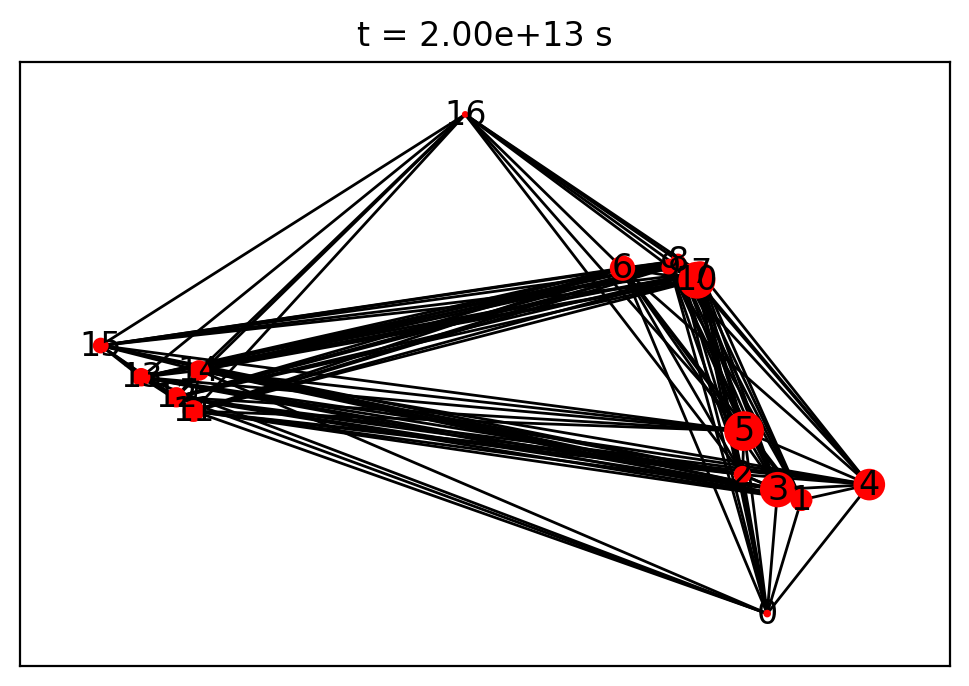

In [348]:
plt.figure(dpi=200)
for seq_i, read_i in enumerate(range(0, counts_by_chamber.shape[0], 1000)):
  plt.clf()
  nx.draw_networkx(G, pos, node_color='r',
                  node_size=counts_by_chamber[read_i,:],
    # edge_cmap=(0, 1), ax=ax, *args, **kwargs)
  )
  plt.title(f"t = {_t[read_i]:.2e} s")
  plt.savefig(f"particle_frame_{seq_i}.png", dpi=200)

In [ ]:
import os
# os.system("ffmpeg -r 20 -i particle_frame_%01d.png -vcodec mpeg4 -vb 10M -y webV40M_particle.mp4")
os.system("ffmpeg -r 20 -i particle_frame_%01d.png -vcodec libx264 -vb 10M -y webV40M_particle_modgraph.mp4")


0

In [ ]:
from IPython.display import Video
Video("webV40M_particle_modgraph.mp4", embed=True)

In [135]:
''' Path counting (particle "genealogy") '''
''' 
Conditional probability P(i|j)?

or

Edge count
'''
# node_i_loc[:,-1]
# Particles that reach the t op
N_nodes = len(G.nodes)
E = np.zeros((N_nodes, N_nodes))
particles_top = node_i_loc[:,node_i_loc[-1,:] == N_nodes-1]
for i, particle_history in enumerate(range(particles_top.shape[1])):
  nodes_visited = np.unique(particles_top[:,i])
  for j in range(len(nodes_visited)-1):
    E[nodes_visited[j], nodes_visited[j+1]] += 1

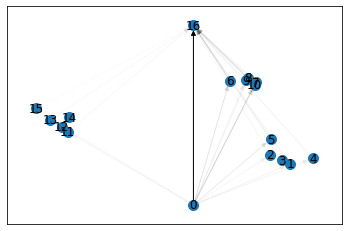

In [142]:
# Take averaged conductivity Y as edge intensity
edge_intensity = (np.array(scipy.sparse.csr_matrix(E).data))
edge_intensity /= edge_intensity.max()

# Create new colormap
from matplotlib.colors import ListedColormap
custom_cmap_array = np.zeros((256,4))
custom_cmap_array[:,3] = np.linspace(0, 1 ,256)
custom_cmap = ListedColormap(custom_cmap_array)

nx.draw_networkx(nx.DiGraph(E), pos,
                node_size=node_size,
                edge_cmap=custom_cmap,
                # edge_cmap=matplotlib.cm.Greys,
                edge_color=edge_intensity, with_labels=True, arrows=True)

In [ ]:
# Assign pseudo-pressure history


T_surf = 20 # deg C
slope = 30/1000 # K / m
geotherm = lambda z: T_surf - slope * (z - z_scale)
lithostat = lambda z: +0 - 2.5e3 * (z - z_scale)
nodal_ambient_T = np.array([geotherm(n.z) for n in _gs.nodes])
lithostatic_p = np.array([lithostat(n.z) for n in _gs.nodes])

In [ ]:
particle_lithostatic_history_top.shape

(200000, 191)

In [211]:
_loaded = np.load("dpdx_100.npz")
p_chambers_100 = _loaded["p"]


In [224]:
p_chamber_adjusted = p_chambers_100[:,:] - 25e6 + lithostatic_p

In [ ]:
p_chamber_adjusted.shape , particles_top[:,:].shape


((200000, 17), (200000, 191))

In [227]:
particle_lithostatic_history = particles_top.copy()
for i in range(particles_top.shape[0]):
  particle_lithostatic_history[i,:] = p_chamber_adjusted[i, particles_top[i,:]]

In [212]:
# Lithostatic pressure history for particles that reach the top
particle_lithostatic_history = lithostatic_p[particles_top[:,:]]

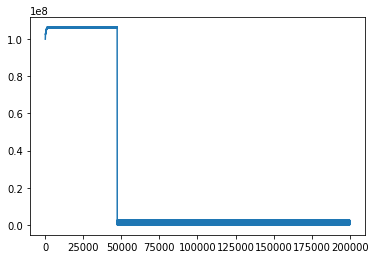

In [235]:
plt.plot(particle_lithostatic_history[:,4])

Tracer particles show a high variability in time spent at given lithostatic pressure:


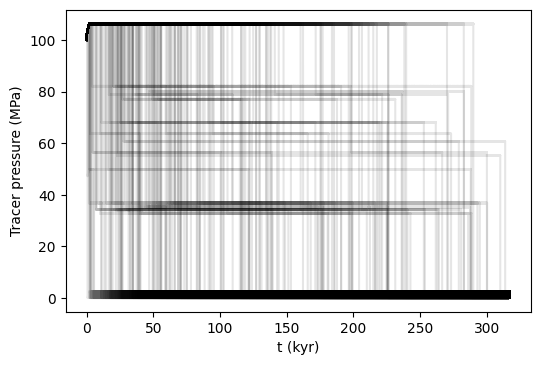

In [249]:
plt.figure(dpi=100)
s_in_yr = 3.154e7
for j in range(particle_lithostatic_history.shape[1]):
  plt.plot(_loaded["t"] / (1e3*s_in_yr), particle_lithostatic_history[:,j] / 1e6,
           color=[0,0,0,0.1])
plt.xlabel("t (kyr)")
plt.ylabel("Tracer pressure (MPa)")

print("Tracer particles show a high variability in time spent at given lithostatic pressure:")

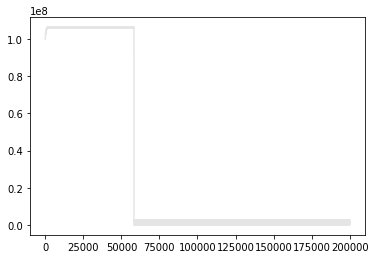

In [239]:
plt.plot(particle_lithostatic_history[:,0], color=[0,0,0,0.1])

In [ ]:
# Lagrangian Eulerian equivalence
# Y_avg vs. particle simulation

In [ ]:
E
nx.draw_networkx(G, pos,
  # node_size=node_size, node_color=colors,
  # edge_cmap=(0, 1), ax=ax, *args, **kwargs)
)

array([[  0.,   6.,   5.,   2.,   6.,   9.,  12.,   8.,   5.,   6.,  13.,
          4.,   2.,   4.,   1.,   3., 105.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   6.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   5.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   2.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   6.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   9.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,  12.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   8.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.

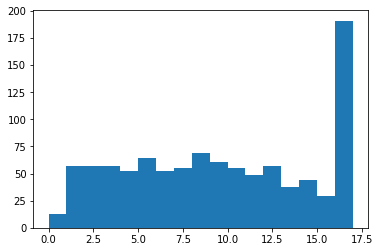

In [49]:
# Last t slice
counts, bins, hist_container = plt.hist(node_i_loc[-1,:],
                                        bins=np.arange(0, x_nodes.shape[0] + 1,))

In [304]:
counts
# On exit, what is the history of a given crystal?
(node_i_loc[-1,:]).min()

0